# Tokenizer Comparison Analysis

Analyse runs from the `AJILE12_TOKENIZER_ABLATION` wandb group.

**Research questions:**
- **Q1:** Spatial session vs per-channel?
- **Q2:** CWT vs ResampleCNN vs per-timepoint?
- **Q3:** Is a learned layer after spatial projection useful?
- **Q4:** Is embed_dim a bottleneck for spatial session + CWT?

In [21]:
import warnings

import wandb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

WANDB_PROJECT = "foundry"
WANDB_GROUP = "AJILE12_TOKENIZER_ABLATION"
PRIMARY_METRIC = "val/ajile_active_behavior_auroc"
SECONDARY_METRICS = [
    "val/ajile_active_behavior_f1",
    "val/ajile_active_behavior_balanced_acc",
]
ALL_METRICS = [PRIMARY_METRIC] + SECONDARY_METRICS

## 1. Fetch runs from W&B

In [22]:
api = wandb.Api()
runs = api.runs(
    WANDB_PROJECT,
    filters={"group": WANDB_GROUP, "state": "finished"},
)
print(f"Found {len(runs)} finished runs in group '{WANDB_GROUP}'")

Found 15 finished runs in group 'AJILE12_TOKENIZER_ABLATION'


In [23]:
records = []
history_frames = []

for run in runs:
    name = run.name  # e.g. ajile_behavior_spatial_session_cwt_fold0
    parts = name.removeprefix("ajile_behavior_").rsplit("_fold", 1)
    tokenizer = parts[0] if len(parts) == 2 else name
    fold = int(parts[1]) if len(parts) == 2 else -1

    summary = run.summary
    record = {
        "run_id": run.id,
        "run_name": name,
        "tokenizer": tokenizer,
        "fold": fold,
    }
    for m in ALL_METRICS:
        record[m] = summary.get(m).get("max")
    record["best_epoch"] = summary.get("trainer/current_epoch", summary.get("epoch"))
    records.append(record)

    hist = run.history(keys=[PRIMARY_METRIC, "val/loss", "train/loss", "epoch"], pandas=True)
    hist["tokenizer"] = tokenizer
    hist["fold"] = fold
    history_frames.append(hist)

df = pd.DataFrame(records)
history_df = pd.concat(history_frames, ignore_index=True)
print(f"Parsed {len(df)} runs across {df['tokenizer'].nunique()} tokenizer configs")
df.head(15)

Parsed 15 runs across 8 tokenizer configs


,run_id,run_name,tokenizer,fold,val/ajile_active_behavior_auroc,val/ajile_active_behavior_f1,val/ajile_active_behavior_balanced_acc,best_epoch
0,3yf95ae2,ajile_behavior_spatial_session_cwt_fold0,spatial_session_cwt,0,0.849206,0.544697,0.550072,30
1,iz7arp77,ajile_behavior_spatial_session_cwt_fold1,spatial_session_cwt,1,0.869066,0.579142,0.578005,29
2,8q3lkxvu,ajile_behavior_spatial_session_cwt_common_fold0,spatial_session_cwt_common,0,0.860588,0.565520,0.558890,28
3,bk0ll1gx,ajile_behavior_spatial_session_cwt_common_fold1,spatial_session_cwt_common,1,0.876721,0.582504,0.595184,28
4,9zy0n2bn,ajile_behavior_spatial_session_resample_cnn_fold0,spatial_session_resample_cnn,0,0.836072,0.516186,0.516156,28
5,b16jjdel,ajile_behavior_spatial_session_resample_cnn_fold1,spatial_session_resample_cnn,1,0.843929,0.533494,0.529081,26
6,n0osz6kg,ajile_behavior_spatial_session_per_timepoint_l...,spatial_session_per_timepoint_linear,0,0.864361,0.547585,0.550482,27
7,y95awhjd,ajile_behavior_spatial_session_per_timepoint_l...,spatial_session_per_timepoint_linear,1,0.873156,0.567245,0.569928,25
8,0h6i80j0,ajile_behavior_spatial_session_per_timepoint_i...,spatial_session_per_timepoint_identity,0,0.865816,0.544999,0.542823,25
9,85mmzxxj,ajile_behavior_spatial_session_per_timepoint_i...,spatial_session_per_timepoint_identity,1,0.871050,0.552388,0.554281,23


## 2. Annotate configs with metadata

In [24]:
SPATIAL_MAP = {
    "per_channel_cwt": "PerChannel",
    "per_channel_resample_cnn": "PerChannel",
    "per_channel_per_timepoint_linear": "PerChannel",
    "spatial_session_cwt": "SpatialSession",
    "spatial_session_cwt_common": "SpatialSession",
    "spatial_session_resample_cnn": "SpatialSession",
    "spatial_session_per_timepoint_linear": "SpatialSession",
    "spatial_session_per_timepoint_identity": "SpatialSession",
    "spatial_session_cwt_dim512": "SpatialSession",
    "per_channel_cwt_dim512": "PerChannel",
    "per_channel_per_timepoint_linear_dim512": "PerChannel",
}

TEMPORAL_MAP = {
    "per_channel_cwt": "CWT",
    "per_channel_resample_cnn": "ResampleCNN",
    "per_channel_per_timepoint_linear": "PerTimepoint",
    "spatial_session_cwt": "CWT",
    "spatial_session_cwt_common": "CWT",
    "spatial_session_resample_cnn": "ResampleCNN",
    "spatial_session_per_timepoint_linear": "PerTimepoint",
    "spatial_session_per_timepoint_identity": "PerTimepoint",
    "spatial_session_cwt_dim512": "CWT",
    "per_channel_cwt_dim512": "CWT",
    "per_channel_per_timepoint_linear_dim512": "PerTimepoint",
}

EMBED_DIM_MAP = {
    "spatial_session_cwt_dim512": 512,
    "per_channel_cwt_dim512": 512,
    "per_channel_per_timepoint_linear_dim512": 512,
}

df["spatial"] = df["tokenizer"].map(SPATIAL_MAP)
df["temporal"] = df["tokenizer"].map(TEMPORAL_MAP)
df["embed_dim"] = df["tokenizer"].map(EMBED_DIM_MAP).fillna(256).astype(int)

# Pretty labels for plots
df["label"] = df["tokenizer"].str.replace("_", " ").str.title()

df[["tokenizer", "spatial", "temporal", "embed_dim", "fold", PRIMARY_METRIC]].sort_values(PRIMARY_METRIC, ascending=False)

,tokenizer,spatial,temporal,embed_dim,fold,val/ajile_active_behavior_auroc
12,per_channel_cwt,PerChannel,CWT,256,1,0.908597
13,per_channel_resample_cnn,PerChannel,ResampleCNN,256,1,0.895372
11,per_channel_cwt,PerChannel,CWT,256,0,0.892314
14,per_channel_resample_cnn,PerChannel,ResampleCNN,256,0,0.886469
3,spatial_session_cwt_common,SpatialSession,CWT,256,1,0.876721
7,spatial_session_per_timepoint_linear,SpatialSession,PerTimepoint,256,1,0.873156
9,spatial_session_per_timepoint_identity,SpatialSession,PerTimepoint,256,1,0.871050
1,spatial_session_cwt,SpatialSession,CWT,256,1,0.869066
8,spatial_session_per_timepoint_identity,SpatialSession,PerTimepoint,256,0,0.865816
6,spatial_session_per_timepoint_linear,SpatialSession,PerTimepoint,256,0,0.864361


In [25]:
agg = (
    df.groupby(["tokenizer", "spatial", "temporal", "embed_dim"])[ALL_METRICS]
    .agg(["mean", "std", "min", "max"])
    .sort_values((PRIMARY_METRIC, "mean"), ascending=False)
)
agg

val/ajile_active_behavior_auroc  \
                                                                                                        mean   
tokenizer                              spatial        temporal     embed_dim                                   
per_channel_cwt                        PerChannel     CWT          256                              0.900455   
per_channel_resample_cnn               PerChannel     ResampleCNN  256                              0.890921   
spatial_session_per_timepoint_linear   SpatialSession PerTimepoint 256                              0.868758   
spatial_session_cwt_common             SpatialSession CWT          256                              0.868655   
spatial_session_per_timepoint_identity SpatialSession PerTimepoint 256                              0.868433   
spatial_session_cwt                    SpatialSession CWT          256                              0.859136   
spatial_session_resample_cnn           SpatialSession ResampleCNN  256                              0.840001   
per_channel_per_timepoint_linear       PerChannel     PerTimepoint 256                              0.775898   

                                                                                        \
                                                                                   std   
tokenizer                              spatial        temporal     embed_dim             
per_channel_cwt                        PerChannel     CWT          256        0.011514   
per_channel_resample_cnn               PerChannel     ResampleCNN  256        0.006295   
spatial_session_per_timepoint_linear   SpatialSession PerTimepoint 256        0.006220   
spatial_session_cwt_common             SpatialSession CWT          256        0.011408   
spatial_session_per_timepoint_identity SpatialSession PerTimepoint 256        0.003701   
spatial_session_cwt                    SpatialSession CWT          256        0.014043   
spatial_session_resample_cnn           SpatialSession ResampleCNN  256        0.005555   
per_channel_per_timepoint_linear       PerChannel     PerTimepoint 256             NaN   

                                                                                        \
                                                                                   min   
tokenizer                              spatial        temporal     embed_dim             
per_channel_cwt                        PerChannel     CWT          256        0.892314   
per_channel_resample_cnn               PerChannel     ResampleCNN  256        0.886469   
spatial_session_per_timepoint_linear   SpatialSession PerTimepoint 256        0.864361   
spatial_session_cwt_common             SpatialSession CWT          256        0.860588   
spatial_session_per_timepoint_identity SpatialSession PerTimepoint 256        0.865816   
spatial_session_cwt                    SpatialSession CWT          256        0.849206   
spatial_session_resample_cnn           SpatialSession ResampleCNN  256        0.836072   
per_channel_per_timepoint_linear       PerChannel     PerTimepoint 256        0.775898   

                                                                                        \
                                                                                   max   
tokenizer                              spatial        temporal     embed_dim             
per_channel_cwt                        PerChannel     CWT          256        0.908597   
per_channel_resample_cnn               PerChannel     ResampleCNN  256        0.895372   
spatial_session_per_timepoint_linear   SpatialSession PerTimepoint 256        0.873156   
spatial_session_cwt_common             SpatialSession CWT          256        0.876721   
spatial_session_per_timepoint_identity SpatialSession PerTimepoint 256        0.871050   
spatial_session_cwt                    SpatialSession CWT          256        0.869066   
spatial_session_resample_cnn           SpatialSessio

## 3. Overview: All configs ranked by AUROC

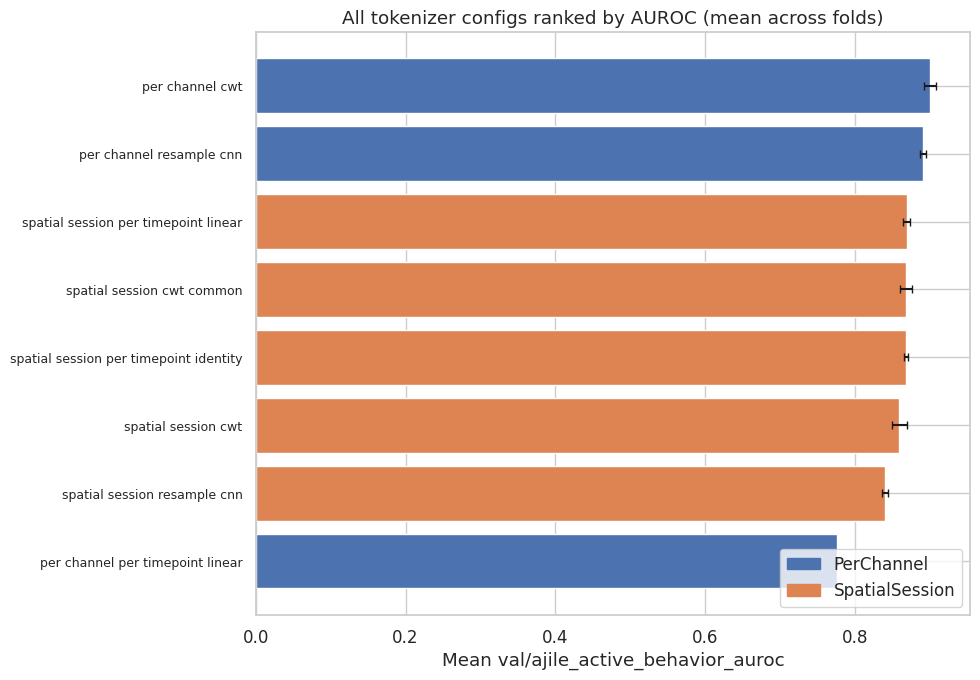

In [33]:
from matplotlib.patches import Patch

summary = (
    df.groupby(["tokenizer", "spatial"])[PRIMARY_METRIC]
    .agg(["mean", "min", "max"])
    .reset_index()
    .sort_values("mean", ascending=True)
)
summary["err_lo"] = summary["mean"] - summary["min"]
summary["err_hi"] = summary["max"] - summary["mean"]

palette = {"PerChannel": "#4C72B0", "SpatialSession": "#DD8452"}
colors = [palette[s] for s in summary["spatial"]]

fig, ax = plt.subplots(figsize=(10, 7))
y_pos = range(len(summary))
ax.barh(
    y_pos,
    summary["mean"],
    xerr=[summary["err_lo"], summary["err_hi"]],
    color=colors,
    edgecolor="white",
    capsize=3,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(summary["tokenizer"].str.replace("_", " "), fontsize=9)
ax.set_xlabel(f"Mean {PRIMARY_METRIC}")
ax.set_title("All tokenizer configs ranked by AUROC (mean across folds)")

ax.legend(
    handles=[Patch(color=col, label=lab) for lab, col in palette.items()],
    loc="lower right",
)
fig.tight_layout()
plt.show()

## 4. Q1 -- Spatial Session vs Per-Channel

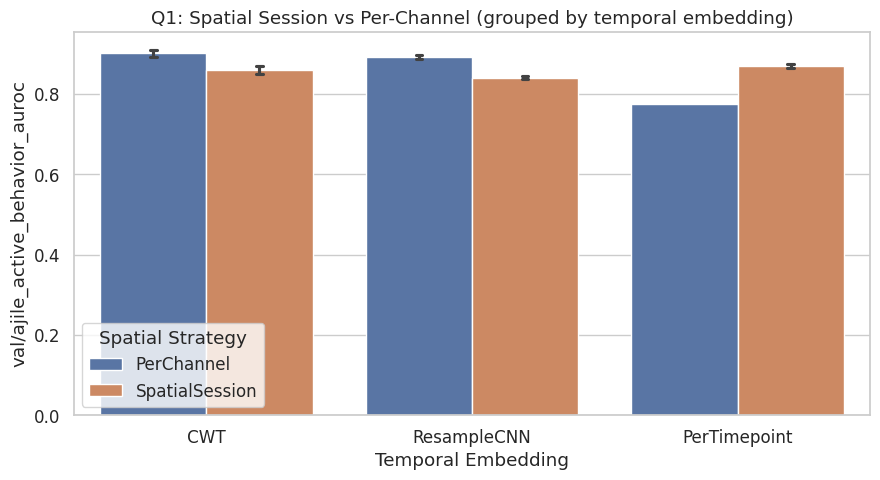

In [27]:
q1_configs = [
    "per_channel_cwt", "spatial_session_cwt",
    "per_channel_resample_cnn", "spatial_session_resample_cnn",
    "per_channel_per_timepoint_linear", "spatial_session_per_timepoint_linear",
]
q1 = df[df["tokenizer"].isin(q1_configs) & (df["embed_dim"] == 256)].copy()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=q1,
    x="temporal",
    y=PRIMARY_METRIC,
    hue="spatial",
    order=["CWT", "ResampleCNN", "PerTimepoint"],
    hue_order=["PerChannel", "SpatialSession"],
    palette=palette,
    capsize=0.05,
    errorbar=("pi", 100),
    ax=ax,
)
ax.set_title("Q1: Spatial Session vs Per-Channel (grouped by temporal embedding)")
ax.set_ylabel(PRIMARY_METRIC)
ax.set_xlabel("Temporal Embedding")
ax.legend(title="Spatial Strategy")
fig.tight_layout()
plt.show()

## 5. Q2 -- CWT vs ResampleCNN vs Per-Timepoint

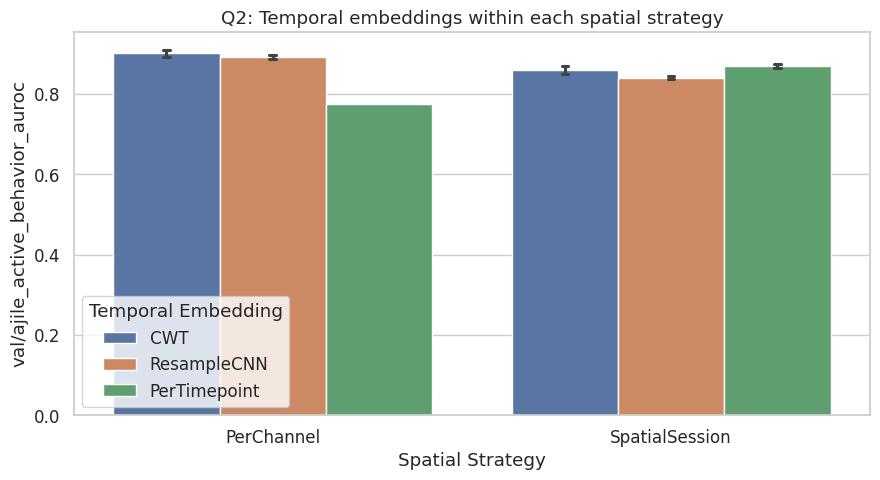

In [28]:
q2 = df[df["tokenizer"].isin(q1_configs) & (df["embed_dim"] == 256)].copy()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=q2,
    x="spatial",
    y=PRIMARY_METRIC,
    hue="temporal",
    order=["PerChannel", "SpatialSession"],
    hue_order=["CWT", "ResampleCNN", "PerTimepoint"],
    capsize=0.05,
    errorbar=("pi", 100),
    ax=ax,
)
ax.set_title("Q2: Temporal embeddings within each spatial strategy")
ax.set_ylabel(PRIMARY_METRIC)
ax.set_xlabel("Spatial Strategy")
ax.legend(title="Temporal Embedding")
fig.tight_layout()
plt.show()

## 6. Q3 -- Learned Post-Projection Layer

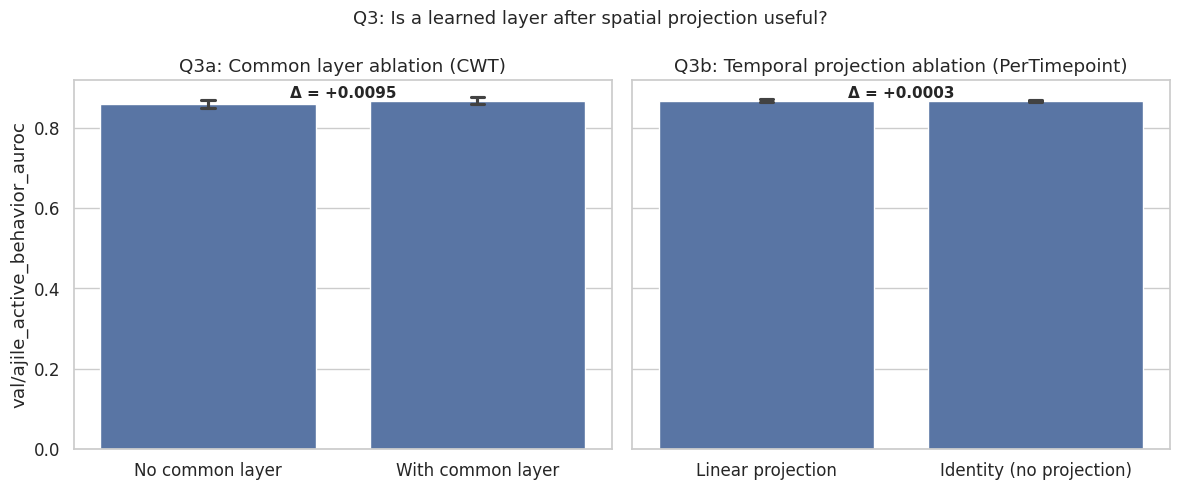

In [29]:
q3a_configs = ["spatial_session_cwt", "spatial_session_cwt_common"]
q3b_configs = ["spatial_session_per_timepoint_identity", "spatial_session_per_timepoint_linear"]

q3a = df[df["tokenizer"].isin(q3a_configs)].copy()
q3a["variant"] = q3a["tokenizer"].map({
    "spatial_session_cwt": "No common layer",
    "spatial_session_cwt_common": "With common layer",
})

q3b = df[df["tokenizer"].isin(q3b_configs)].copy()
q3b["variant"] = q3b["tokenizer"].map({
    "spatial_session_per_timepoint_identity": "Identity (no projection)",
    "spatial_session_per_timepoint_linear": "Linear projection",
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.barplot(
    data=q3a, x="variant", y=PRIMARY_METRIC,
    capsize=0.05, errorbar=("pi", 100), ax=axes[0],
)
axes[0].set_title("Q3a: Common layer ablation (CWT)")
axes[0].set_xlabel("")
axes[0].set_ylabel(PRIMARY_METRIC)

# Annotate delta
means_a = q3a.groupby("variant")[PRIMARY_METRIC].mean()
if len(means_a) == 2:
    delta_a = means_a.iloc[1] - means_a.iloc[0]
    axes[0].annotate(
        f"\u0394 = {delta_a:+.4f}",
        xy=(0.5, 0.95), xycoords="axes fraction",
        ha="center", fontsize=11, fontweight="bold",
    )

sns.barplot(
    data=q3b, x="variant", y=PRIMARY_METRIC,
    capsize=0.05, errorbar=("pi", 100), ax=axes[1],
)
axes[1].set_title("Q3b: Temporal projection ablation (PerTimepoint)")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

means_b = q3b.groupby("variant")[PRIMARY_METRIC].mean()
if len(means_b) == 2:
    delta_b = means_b.iloc[1] - means_b.iloc[0]
    axes[1].annotate(
        f"\u0394 = {delta_b:+.4f}",
        xy=(0.5, 0.95), xycoords="axes fraction",
        ha="center", fontsize=11, fontweight="bold",
    )

fig.suptitle("Q3: Is a learned layer after spatial projection useful?", fontsize=13)
fig.tight_layout()
plt.show()

## 7. Q4 -- Embed Dim Scaling

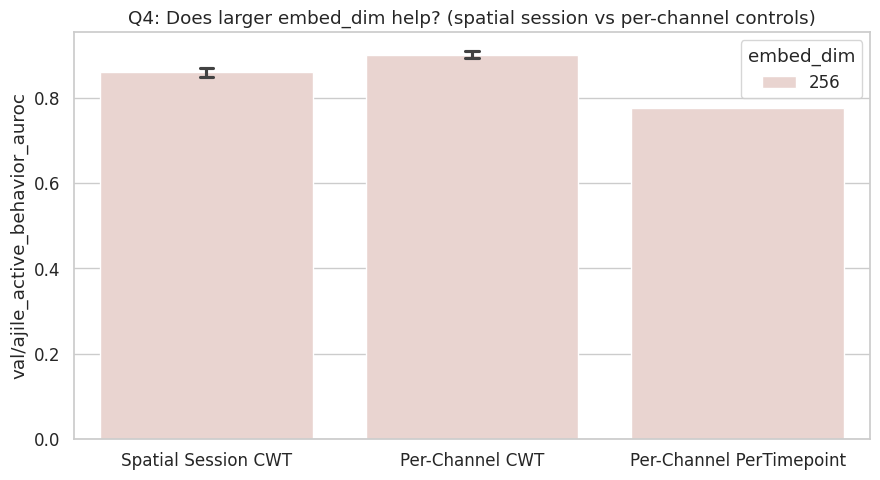

In [30]:
q4_groups = {
    "Spatial Session CWT": ["spatial_session_cwt", "spatial_session_cwt_dim512"],
    "Per-Channel CWT": ["per_channel_cwt", "per_channel_cwt_dim512"],
    "Per-Channel PerTimepoint": ["per_channel_per_timepoint_linear", "per_channel_per_timepoint_linear_dim512"],
}

q4 = df[df["tokenizer"].isin(
    [t for group in q4_groups.values() for t in group]
)].copy()

q4["config_group"] = q4["tokenizer"].map(
    {t: grp for grp, ts in q4_groups.items() for t in ts}
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=q4,
    x="config_group",
    y=PRIMARY_METRIC,
    hue="embed_dim",
    order=["Spatial Session CWT", "Per-Channel CWT", "Per-Channel PerTimepoint"],
    capsize=0.05,
    errorbar=("pi", 100),
    ax=ax,
)
ax.set_title("Q4: Does larger embed_dim help? (spatial session vs per-channel controls)")
ax.set_ylabel(PRIMARY_METRIC)
ax.set_xlabel("")
ax.legend(title="embed_dim")
fig.tight_layout()
plt.show()

## 8. Training Curves

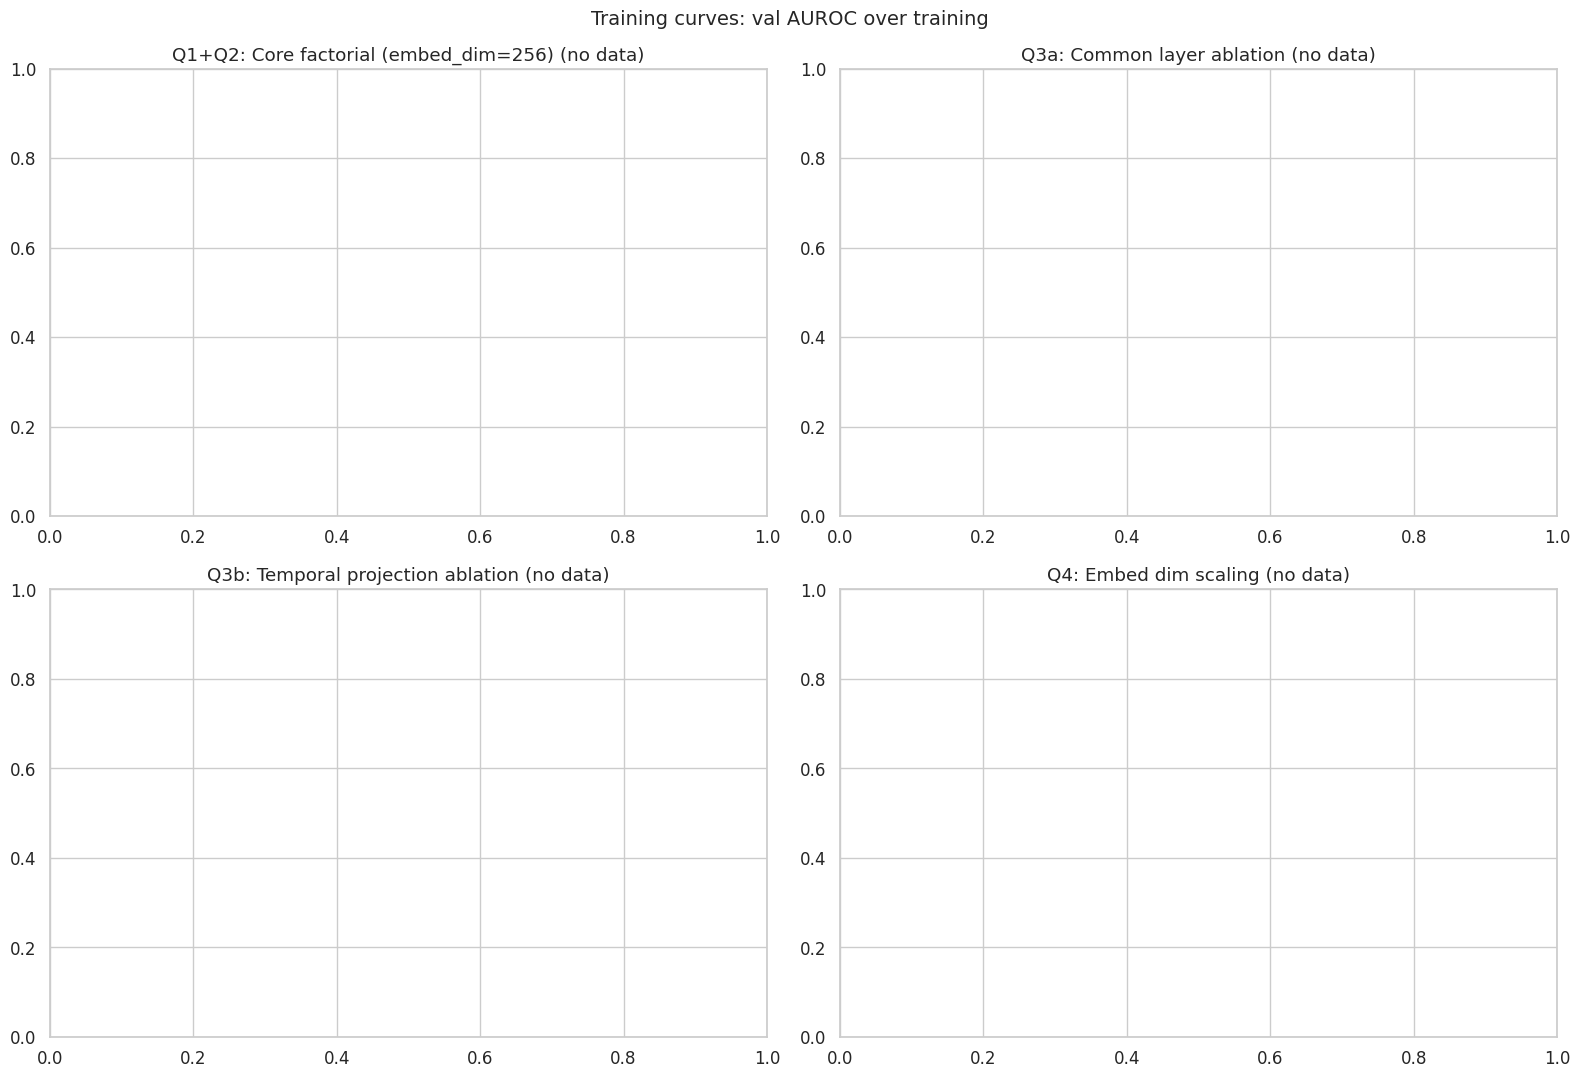

In [31]:
curve_groups = {
    "Q1+Q2: Core factorial (embed_dim=256)": q1_configs,
    "Q3a: Common layer ablation": q3a_configs,
    "Q3b: Temporal projection ablation": q3b_configs,
    "Q4: Embed dim scaling": [
        "spatial_session_cwt", "spatial_session_cwt_dim512",
        "per_channel_cwt", "per_channel_cwt_dim512",
        "per_channel_per_timepoint_linear", "per_channel_per_timepoint_linear_dim512",
    ],
}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for ax, (title, configs) in zip(axes.flat, curve_groups.items()):
    subset = history_df[history_df["tokenizer"].isin(configs)].copy()
    if subset.empty:
        ax.set_title(f"{title} (no data)")
        continue
    subset["run_label"] = subset["tokenizer"] + " fold" + subset["fold"].astype(str)
    for label, grp in subset.groupby("run_label"):
        grp_sorted = grp.dropna(subset=[PRIMARY_METRIC]).sort_values("_step")
        if grp_sorted.empty:
            continue
        ax.plot(grp_sorted["_step"], grp_sorted[PRIMARY_METRIC], label=label, alpha=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Step")
    ax.set_ylabel(PRIMARY_METRIC)
    ax.legend(fontsize=7, ncol=2, loc="lower right")

fig.suptitle("Training curves: val AUROC over training", fontsize=14)
fig.tight_layout()
plt.show()

## 9. Summary Table

In [32]:
summary_table = (
    df.groupby(["tokenizer", "spatial", "temporal", "embed_dim"])
    .agg(
        auroc_mean=(PRIMARY_METRIC, "mean"),
        auroc_std=(PRIMARY_METRIC, "std"),
        f1_mean=("val/ajile_active_behavior_f1", "mean"),
        f1_std=("val/ajile_active_behavior_f1", "std"),
        balanced_acc_mean=("val/ajile_active_behavior_balanced_acc", "mean"),
        balanced_acc_std=("val/ajile_active_behavior_balanced_acc", "std"),
        best_epoch_mean=("best_epoch", "mean"),
    )
    .sort_values("auroc_mean", ascending=False)
    .reset_index()
)

def highlight_best(s):
    if s.name.endswith("_mean"):
        is_best = s == s.max()
        return ["font-weight: bold" if v else "" for v in is_best]
    return ["" for _ in s]

summary_table.style.apply(highlight_best).format(precision=4)

,tokenizer,spatial,temporal,embed_dim,auroc_mean,auroc_std,f1_mean,f1_std,balanced_acc_mean,balanced_acc_std,best_epoch_mean
0,per_channel_cwt,PerChannel,CWT,256,0.9005,0.0115,0.6219,0.0192,0.6172,0.0222,65.5000
1,per_channel_resample_cnn,PerChannel,ResampleCNN,256,0.8909,0.0063,0.5988,0.0053,0.5965,0.0112,79.0000
2,spatial_session_per_timepoint_linear,SpatialSession,PerTimepoint,256,0.8688,0.0062,0.5574,0.0139,0.5602,0.0138,26.0000
3,spatial_session_cwt_common,SpatialSession,CWT,256,0.8687,0.0114,0.5740,0.0120,0.5770,0.0257,28.0000
4,spatial_session_per_timepoint_identity,SpatialSession,PerTimepoint,256,0.8684,0.0037,0.5487,0.0052,0.5486,0.0081,24.0000
5,spatial_session_cwt,SpatialSession,CWT,256,0.8591,0.0140,0.5619,0.0244,0.5640,0.0198,29.5000
6,spatial_session_resample_cnn,SpatialSession,ResampleCNN,256,0.8400,0.0056,0.5248,0.0122,0.5226,0.0091,27.0000
7,per_channel_per_timepoint_linear,PerChannel,PerTimepoint,256,0.7759,nan,0.4024,nan,0.4162,nan,25.0000
